In [ ]:
from pathlib import Path
import pandas as pd

def find_root(start: Path = Path.cwd()) -> Path:
    # Look for a directory that has 'data' and 'reports', walk up from current working dir
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "reports").exists():
            return p
    return start

ROOT = find_root()
DATA_DIR = ROOT / "data" / "raw"
FIG_DIR  = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
df = pd.read_excel(DATA_DIR / "stat_423001.xls", skiprows=2, nrows=1, index_col=0)
df

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
조혼인율(‰),9.2,7.3,7.3,7.6,7.5,8.0,8.0,8.3,9.3,9.4,...,6.0,5.9,5.5,5.2,5.0,4.7,4.2,3.8,3.7,3.8


In [32]:
# Transposing index and columns
df = df.T

# Renaming row index
df.columns = ['Crude Marriage Rate (%)']

# Make sure both axes are numeric
df.index = pd.to_numeric(df.index, errors='coerce')     
df['Crude Marriage Rate (%)'] = pd.to_numeric(
    df['Crude Marriage Rate (%)'], errors='coerce'
)
df = df.dropna()

df.head()

,Crude Marriage Rate (%)
1970,9.2
1971,7.3
1972,7.3
1973,7.6
1974,7.5


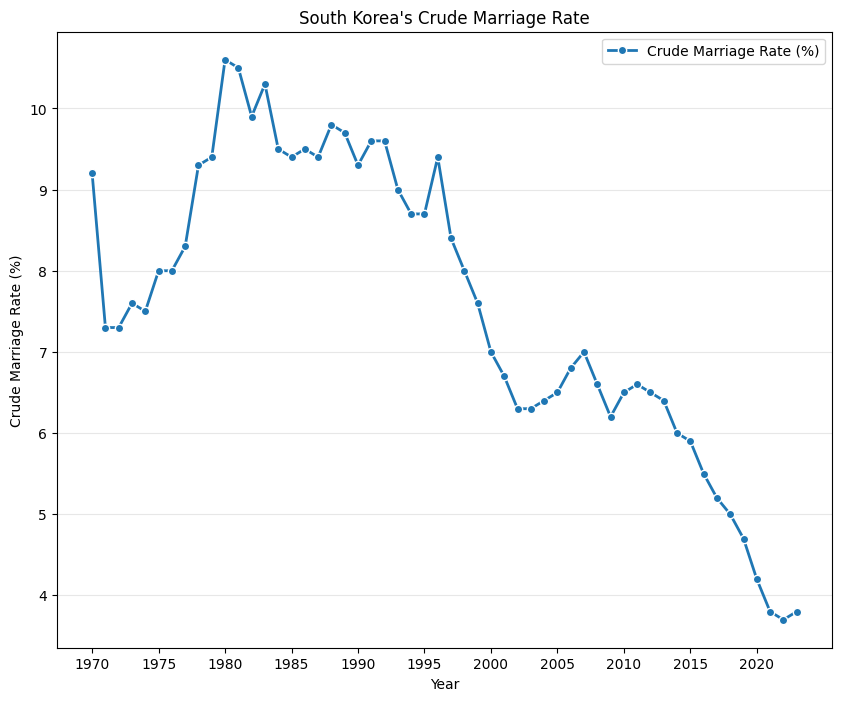

In [33]:
# Plot
x = df.index.values
y = df.iloc[:, 0].values

plt.figure(figsize=(10, 8))
plt.plot(
    x, y,
    marker='o', ms=6, lw=2, mec='w', mew=1,
    label='Crude Marriage Rate (%)'    
)
plt.title("South Korea's Crude Marriage Rate")
plt.xlabel("Year")
plt.ylabel("Crude Marriage Rate (%)")
plt.xticks(x[::5])                    
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.show()
